In [23]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Cleaner styling for plots
sns.set()

In [25]:
# --- DATA CLEANING SECTION ---
# Cleaning is required because the raw dataset contains missing values in critical columns 
# (Director, Cast, Country), incorrect data types for dates, and redundant string 
# information in numerical fields.

In [26]:
# Load the dataset
df = pd.read_csv("netflix_titles.csv")
# DisplaY all rows
df.head(-1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...


In [27]:
print(df.isna())

      show_id   type  title  director   cast  country  date_added  \
0       False  False  False     False   True    False       False   
1       False  False  False      True  False    False       False   
2       False  False  False     False  False     True       False   
3       False  False  False      True   True     True       False   
4       False  False  False      True  False    False       False   
...       ...    ...    ...       ...    ...      ...         ...   
8802    False  False  False     False  False    False       False   
8803    False  False  False      True   True     True       False   
8804    False  False  False     False  False    False       False   
8805    False  False  False     False  False    False       False   
8806    False  False  False     False  False    False       False   

      release_year  rating  duration  listed_in  description  
0            False   False     False      False        False  
1            False   False     False      Fal

In [28]:
print(df.isna().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [29]:
# Check dataset dimensions

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])


Shape (rows, columns):  (8807, 12) 

number of rows:  8807
number of columns:  12


In [30]:
# Check data types
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [31]:
# 1. Handle Missing Values:
# The 'country' column is essential for regional analysis. We fill missing values 
# with the mode (the most frequent country) to keep the data representative.
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [32]:
# Drop other rows with missing critical data (like 'date_added' or 'duration') 
# to ensure the analysis is based on complete records.
df.dropna(inplace=True)

In [33]:
# 2. Correct Data Formats:
# 'date_added' is loaded as a string. We convert it to datetime objects to 
# perform time-series analysis and extract years/months.
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [34]:
# 3. Numerical Data Extraction:
# For Movie duration analysis, we strip the ' min' string and convert 
# to float to allow for mathematical correlation.
movies_only = df[df['type'] == 'Movie'].copy()
movies_only['duration_min'] = movies_only['duration'].str.replace(' min', '').astype(float)

In [35]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
count,5696,5696,5696,5696,5696,5696,5696,5696.000000,5696,5696,5696,5696,5696.000000,5696.000000
unique,5696,2,5696,4150,5510,604,NaN,NaN,14,205,346,5673,NaN,NaN
top,s3,Movie,Ganglands,"Raúl Campos, Jan Suter","Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",United States,NaN,NaN,TV-MA,94 min,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,NaN
freq,1,5518,1,18,13,2210,NaN,NaN,1939,140,361,4,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-28 17:52:40.112359680,2012.978581,NaN,NaN,NaN,NaN,2018.906952,6.626580
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1942.000000,NaN,NaN,NaN,NaN,2008.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-05-04 00:00:00,2012.000000,NaN,NaN,NaN,NaN,2018.000000,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-22 12:00:00,2016.000000,NaN,NaN,NaN,NaN,2019.000000,7.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-13 00:00:00,2018.000000,NaN,NaN,NaN,NaN,2020.000000,10.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-24 00:00:00,2021.000000,NaN,NaN,NaN,NaN,2021.000000,12.000000


In [36]:
df.shape

(5696, 14)

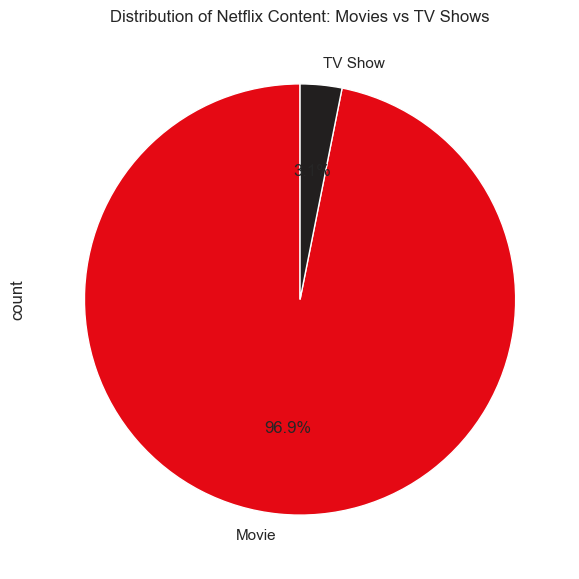

In [37]:
# --- VISUALIZATION & INSIGHTS ---

# Plot 1: Content Distribution (Pie Chart)
# Chosen to show the high-level split between the two main content categories.
# Insight: Movies dominate the platform, comprising over 90% of this cleaned dataset.
plt.figure(figsize=(7,7))
df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#e50914', '#221f1f'], startangle=90)
plt.title('Distribution of Netflix Content: Movies vs TV Shows')
plt.show()

/var/folders/32/8ysq6g8j3dd1l1flvjdtx7y00000gn/T/ipykernel_17346/3341845327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


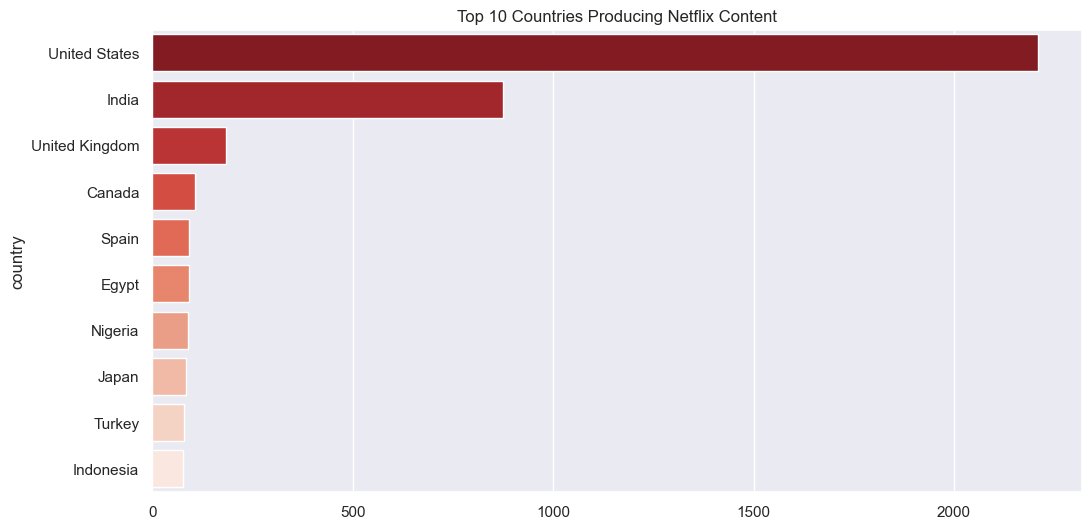

In [38]:
# Plot 2: Top 10 Countries (Bar Chart)
# Chosen to identify the primary regional markets and production hubs.
# Insight: The US, India, and the UK are the top global producers for Netflix.
plt.figure(figsize=(12,6))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Countries Producing Netflix Content')
plt.show()




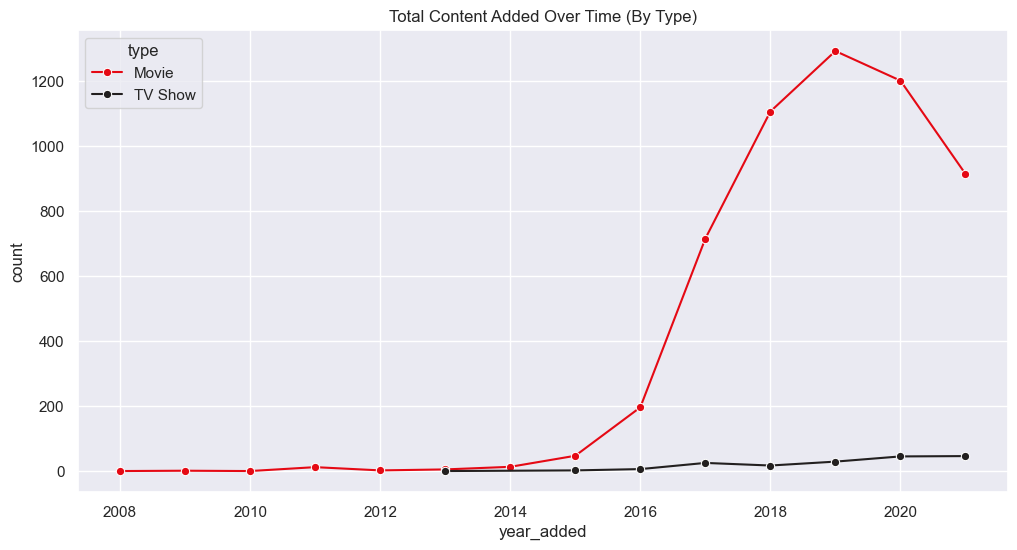

In [39]:
# Plot 3: Content Added Over Time (Line Chart)
# Chosen to visualize the historical growth and expansion of the library.
# Insight: There was a significant surge in content addition starting around 2015, peaking near 2019.
plt.figure(figsize=(12,6))
df_yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')
sns.lineplot(data=df_yearly, x='year_added', y='count', hue='type', palette=['#e50914', '#221f1f'], marker='o')
plt.title('Total Content Added Over Time (By Type)')
plt.show()

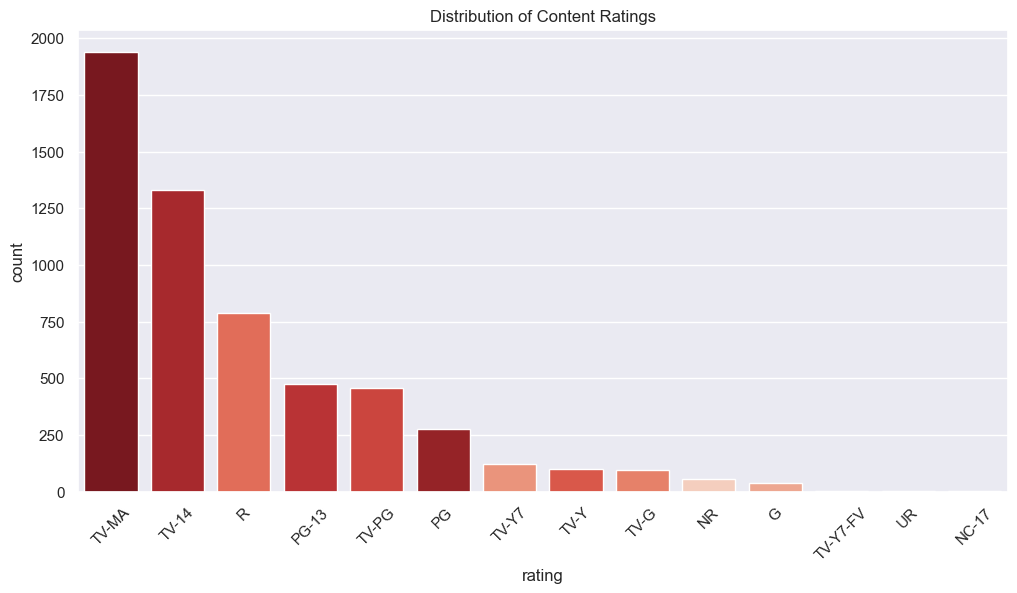

In [40]:
# Plot 4: Rating Distribution (Count Plot)
# Chosen to determine the target audience and content maturity levels.
# Insight: TV-MA (Mature) and TV-14 are most common, indicating a focus on adult/teen viewers.
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='Reds_r', hue='rating', legend=False)
plt.title('Distribution of Content Ratings')
plt.xticks(rotation=45)
plt.show()

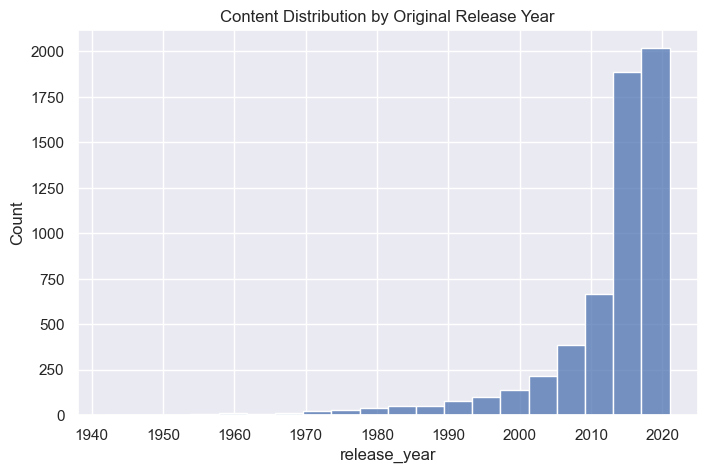

In [41]:
# Plot 5: Release Year (Histogram)
# Chosen to see the age profile of the movies and shows in the library.
# Insight: Most content is very modern, with a massive concentration of titles released after 2010.
plt.figure(figsize=(8,5))
sns.histplot(df['release_year'], bins=20)
plt.title("Content Distribution by Original Release Year")
plt.show()

/var/folders/32/8ysq6g8j3dd1l1flvjdtx7y00000gn/T/ipykernel_17346/4031679614.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, palette='OrRd')


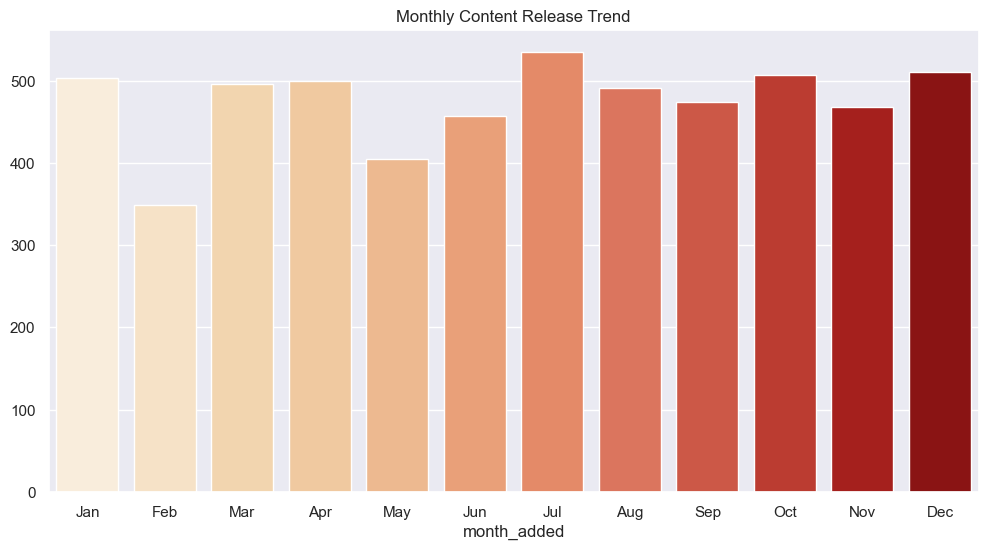

In [42]:
# Plot 6: Monthly Trends (Bar Chart)
# Chosen to see if Netflix follows seasonal trends for releasing content.
# Insight: Content addition is fairly consistent, with slight peaks in late summer and winter holiday months.
month_counts = df['month_added'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.barplot(x=month_counts.index, y=month_counts.values, palette='OrRd')
plt.xticks(ticks=range(0,12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Content Release Trend')
plt.show()

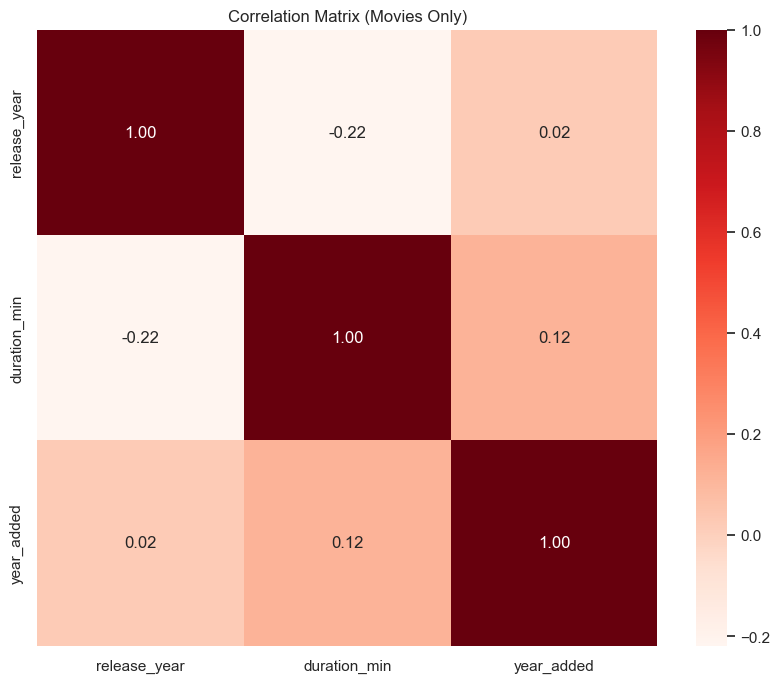

In [43]:
# Plot 7: Correlation Matrix (Heatmap)
# Chosen to find hidden relationships between release year, duration, and add date.
# Insight: There is a very low correlation between movie length and release year, 
# suggesting duration doesn't strictly follow historical trends.
numerical_df = movies_only[['release_year', 'duration_min', 'year_added']]
plt.figure(figsize=(10,8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title('Correlation Matrix (Movies Only)')
plt.show()